# Laboratorio 7 — Spark MLlib
---

## 0. Configuración inicial

Importamos librerías, iniciamos la sesión de Spark y definimos rutas y parámetros globales del notebook.

In [1]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import ClusteringEvaluator, RegressionEvaluator
from pyspark.ml import Pipeline

try:
    import jdk4py
    os.environ.setdefault("JAVA_HOME", str(jdk4py.JAVA_HOME))
except ImportError:
    pass

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (SparkSession.builder
         .appName("Lab7_SparkMLlib_ENEIC")
         .master("local[*]")
         .config("spark.driver.host", "127.0.0.1")
         .config("spark.driver.bindAddress", "127.0.0.1")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
spark


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/27 19:26:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/09/27 19:26:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
# ------------------------------------------------------------------
# RUTAS Y PARÁMETROS GLOBALES
# ------------------------------------------------------------------
# Resolver rutas tanto si el kernel corre desde la raíz del repo como desde notebooks/.
CWD = os.getcwd()
PROJECT_ROOT = CWD if os.path.isdir(os.path.join(CWD, "data")) else os.path.abspath(os.path.join(CWD, ".."))
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")          # carpeta con los .xlsx originales de la ENEIC
PARQUET_DIR = os.path.join(PROJECT_ROOT, "data", "parquet")  # carpeta de salida para los datos preparados
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")               # carpeta para guardar modelos ajustados
SAMPLE_MAX = 8000             # tamaño máximo de muestra SOLO para graficar
SEED = 42

os.makedirs(PARQUET_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

FILE_MAP = {
    "2025T1": {"path": os.path.join(RAW_DIR, "Personas_2025_T1.xlsx"), "anio": 2025, "trim_cal": 1, "uso": "train"},
    "2025T2": {"path": os.path.join(RAW_DIR, "Personas_2025_T2.xlsx"), "anio": 2025, "trim_cal": 2, "uso": "train"},
    "2025T3": {"path": os.path.join(RAW_DIR, "Personas_2025_T3.xlsx"), "anio": 2025, "trim_cal": 3, "uso": "train"},
    "2025T4": {"path": os.path.join(RAW_DIR, "Personas_2025_T4.xlsx"), "anio": 2025, "trim_cal": 4, "uso": "train"},
    "2026T1": {"path": os.path.join(RAW_DIR, "Personas_2026_T1.xlsx"), "anio": 2026, "trim_cal": 1, "uso": "test"},
}

faltantes_archivos = [info["path"] for info in FILE_MAP.values() if not os.path.exists(info["path"])]
if faltantes_archivos:
    raise FileNotFoundError("Faltan archivos requeridos: " + ", ".join(faltantes_archivos))

# Columnas originales que se conservan del archivo fuente (ver tabla "Variables que utilizará")
REQUIRED_COLS = [
    "NUM_HOGAR", "NUM_PERSONA",      # auditoría de registros
    "FACTOR",                         # diseño muestral (no se usa para ponderar en este lab)
    "ANIO", "TRIMESTRE",              # auditoría de la fuente (TRIMESTRE NO es el calendario)
    "OCUPADOS",                       # filtro
    "P05C16",                         # categoria_ocupacional (filtro + predictor)
    "P05D01",                         # salario_mensual (variable objetivo)
    "P02A03",                         # edad
    "P05C07A", "P05C07B",             # antiguedad_anios, antiguedad_meses
    "P05H01A",                        # horas_semanales
    "P03A03A",                        # nivel_educativo
    "DOMINIO",                        # dominio
]


## 1. Carga, armonización y calidad de datos — (5 pts)

**Enfoque:**
1. Cada archivo Excel se lee con `pandas`/`openpyxl` **como texto (`dtype=str`)**. Esto es
   clave: en la ENEIC un mismo código puede llegar como número (`1`) o como texto con
   decimales espurios (`"1.0"`), y leer todo como texto nos permite normalizarlo de forma
   uniforme *antes* de convertir a Spark, en vez de arrastrar inconsistencias de tipo.
2. Se seleccionan únicamente las columnas requeridas (esto resuelve el problema de que el
   archivo de IV-2025 tiene 302 columnas en vez de 270: al elegir el mismo subconjunto de
   columnas en todos los archivos, `unionByName` los puede unir sin importar cuántas
   columnas tenía cada archivo originalmente).
3. Se agregan `archivo_origen`, `periodo_archivo`, `anio_archivo` y `trimestre_calendario`
   a partir del archivo de procedencia (NO a partir de la columna `TRIMESTRE`, que trae
   valores inconsistentes entre archivos: 2, 3, 4, 5 y 6, y que en II-2025 mezcla 3 y 2).
4. Se homologan los códigos categóricos a una representación de texto consistente
   (quitando sufijos `".0"` que aparecen cuando el valor llegó como numérico).
5. Se hace `unionByName` de los cuatro trimestres de 2025.


In [3]:
def leer_archivo_personas(periodo, path, anio, trim_cal):
    """Lee un archivo de Personas de la ENEIC, selecciona columnas requeridas y
    agrega las columnas de identificación de período. Devuelve (spark_df, n_original)."""
    pdf = pd.read_excel(path, dtype=str)
    faltan = [c for c in REQUIRED_COLS if c not in pdf.columns]
    if faltan:
        raise ValueError(f"[{periodo}] Faltan columnas requeridas: {faltan}")

    n_original = len(pdf)
    pdf = pdf[REQUIRED_COLS].copy()

    sdf = spark.createDataFrame(pdf)
    sdf = (sdf
           .withColumn("archivo_origen", F.lit(periodo))
           .withColumn("periodo_archivo", F.lit(periodo))
           .withColumn("anio_archivo", F.lit(int(anio)))
           .withColumn("trimestre_calendario", F.lit(int(trim_cal))))
    return sdf, n_original


def normalizar_codigo(colname):
    """Convierte una columna de texto a una representación de código consistente:
    quita espacios y el sufijo '.0' que aparece cuando el dato llegó como numérico."""
    c = F.trim(F.col(colname).cast("string"))
    c = F.regexp_replace(c, r"\.0$", "")
    return F.when((c == "") | c.isNull(), None).otherwise(c)


# --- Cargar los 4 trimestres de 2025 ---
dfs_2025 = []
registros_originales = {}
for periodo in ["2025T1", "2025T2", "2025T3", "2025T4"]:
    info = FILE_MAP[periodo]
    sdf, n_orig = leer_archivo_personas(periodo, info["path"], info["anio"], info["trim_cal"])
    dfs_2025.append(sdf)
    registros_originales[periodo] = n_orig

df_2025 = dfs_2025[0]
for d in dfs_2025[1:]:
    df_2025 = df_2025.unionByName(d)

df_2025.persist()
print("Registros originales por archivo (2025):", registros_originales)
print("Total tras unionByName:", df_2025.count())


Registros originales por archivo (2025): {'2025T1': 51588, '2025T2': 51167, '2025T3': 51583, '2025T4': 49338}



[Stage 0:================>                                         (9 + 8) / 32]



Total tras unionByName: 203676


In [4]:
# --- Esquema y 5 registros de las columnas seleccionadas ---
df_2025.printSchema()
df_2025.select(*REQUIRED_COLS, "archivo_origen", "periodo_archivo",
               "anio_archivo", "trimestre_calendario").show(5, truncate=False)


root
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: string (nullable = true)
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- P05D01: string (nullable = true)
 |-- P02A03: string (nullable = true)
 |-- P05C07A: string (nullable = true)
 |-- P05C07B: string (nullable = true)
 |-- P05H01A: string (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)



+---------+-----------+------+----+---------+--------+------+------+------+-------+-------+-------+-------+-------+--------------+---------------+------------+--------------------+
|NUM_HOGAR|NUM_PERSONA|FACTOR|ANIO|TRIMESTRE|OCUPADOS|P05C16|P05D01|P02A03|P05C07A|P05C07B|P05H01A|P03A03A|DOMINIO|archivo_origen|periodo_archivo|anio_archivo|trimestre_calendario|
+---------+-----------+------+----+---------+--------+------+------+------+-------+-------+-------+-------+-------+--------------+---------------+------------+--------------------+
|13796    |3          |338   |2025|2        |NaN     |NaN   |NaN   |14    |NaN    |NaN    |NaN    |3      |2      |2025T1        |2025T1         |2025        |1                   |
|13796    |1          |338   |2025|2        |1       |6     |NaN   |42    |23     |0      |35     |5      |2      |2025T1        |2025T1         |2025        |1                   |
|13796    |2          |338   |2025|2        |1       |1     |7000  |42    |20     |0      |1   

In [5]:
# --- Cargar también I-2026 (se preparará igual, pero se guarda por separado: es TEST) ---
info_2026 = FILE_MAP["2026T1"]
df_2026, n_orig_2026 = leer_archivo_personas("2026T1", info_2026["path"],
                                              info_2026["anio"], info_2026["trim_cal"])
df_2026.persist()
registros_originales["2026T1"] = n_orig_2026
print("Registros originales I-2026:", n_orig_2026)


Registros originales I-2026: 49843


### Homologación de tipos y armonización de códigos

Se castean las variables numéricas a `double` y se normalizan las variables categóricas
(`P05C16`, `P03A03A`, `DOMINIO`, `OCUPADOS`, `NUM_HOGAR`, `NUM_PERSONA`) a texto consistente
con `normalizar_codigo`. El código educativo `"0"` (ninguno) se conserva explícitamente y
**no** se trata como faltante.


In [6]:
def armonizar_tipos(sdf):
    sdf = (sdf
        .withColumn("NUM_HOGAR", normalizar_codigo("NUM_HOGAR"))
        .withColumn("NUM_PERSONA", normalizar_codigo("NUM_PERSONA"))
        .withColumn("OCUPADOS", normalizar_codigo("OCUPADOS"))
        .withColumn("ocupado", F.col("OCUPADOS"))
        .withColumn("categoria_ocupacional", normalizar_codigo("P05C16"))
        .withColumn("nivel_educativo", normalizar_codigo("P03A03A"))
        .withColumn("dominio", normalizar_codigo("DOMINIO"))
        .withColumn("salario_mensual", F.col("P05D01").cast(T.DoubleType()))
        .withColumn("edad", F.col("P02A03").cast(T.DoubleType()))
        .withColumn("antiguedad_anios", F.col("P05C07A").cast(T.DoubleType()))
        .withColumn("antiguedad_meses", F.col("P05C07B").cast(T.DoubleType()))
        .withColumn("horas_semanales", F.col("P05H01A").cast(T.DoubleType()))
        .withColumn("FACTOR", F.col("FACTOR").cast(T.DoubleType()))
        .withColumn("ANIO", F.col("ANIO").cast(T.IntegerType()))
        .withColumn("TRIMESTRE", F.col("TRIMESTRE").cast(T.IntegerType()))
    )
    return sdf

df_2025_tip = armonizar_tipos(df_2025)
df_2026_tip = armonizar_tipos(df_2026)
df_2025_tip.persist()
df_2026_tip.persist()
df_2025_tip.select("categoria_ocupacional", "nivel_educativo", "dominio",
                    "salario_mensual", "edad", "antiguedad_anios",
                    "antiguedad_meses", "horas_semanales").show(5)


+---------------------+---------------+-------+---------------+----+----------------+----------------+---------------+
|categoria_ocupacional|nivel_educativo|dominio|salario_mensual|edad|antiguedad_anios|antiguedad_meses|horas_semanales|
+---------------------+---------------+-------+---------------+----+----------------+----------------+---------------+
|                  NaN|              3|      2|            NaN|14.0|             NaN|             NaN|            NaN|
|                    6|              5|      2|            NaN|42.0|            23.0|             0.0|           35.0|
|                    1|              5|      2|         7000.0|42.0|            20.0|             0.0|            1.0|
|                  NaN|              2|      2|            NaN| 9.0|             NaN|             NaN|            NaN|
|                  NaN|              2|      2|            NaN|11.0|             NaN|             NaN|            NaN|
+---------------------+---------------+-------+-

### Faltantes por variable (antes de aplicar filtros)

Se calcula cantidad y porcentaje de nulos/vacíos para cada variable clave, **sobre la unión
de 2025 sin filtrar todavía**.


In [7]:
KEY_COLS = ["salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses",
            "horas_semanales", "nivel_educativo", "categoria_ocupacional",
            "dominio", "ocupado"]

n_total_2025 = df_2025_tip.count()
filas_faltantes = []
for c in KEY_COLS:
    n_null = df_2025_tip.filter(F.col(c).isNull() | (F.col(c).cast("string") == "")).count()
    filas_faltantes.append((c, n_null, round(100 * n_null / n_total_2025, 2)))

faltantes_pdf = pd.DataFrame(filas_faltantes, columns=["variable", "n_faltantes", "pct_faltantes"])
faltantes_pdf


,variable,n_faltantes,pct_faltantes
0,salario_mensual,0,0.0
1,edad,0,0.0
2,antiguedad_anios,0,0.0
3,antiguedad_meses,0,0.0
4,horas_semanales,0,0.0
5,nivel_educativo,0,0.0
6,categoria_ocupacional,0,0.0
7,dominio,0,0.0
8,ocupado,0,0.0


### Filtros de población analítica

Se aplican en un **orden fijo** para poder contabilizar cuántos registros se excluyen en
cada paso. Nótese el uso explícito de `isnan()` (además de `isNotNull()`): en Spark, un
valor `NaN` se considera *mayor* que cualquier otro número, por lo que un filtro como
`salario_mensual > 0` **no** excluye los `NaN` por sí solo. Por eso se define un helper
`es_finito` que exige que el valor no sea nulo, no sea `NaN` y no sea `+/-Infinito`.


In [8]:
def es_finito(colname):
    c = F.col(colname)
    return c.isNotNull() & (~F.isnan(c)) & (c != float("inf")) & (c != float("-inf"))


def preparar_poblacion_analitica(sdf, etiqueta):
    """Aplica los filtros de la población analítica en orden fijo, registrando
    cuántos registros se excluyen en cada paso."""
    pasos = [("0_inicial", sdf.count())]
    d = sdf

    d = d.filter(es_finito("edad") & (F.col("edad") >= 15))
    pasos.append(("1_edad>=15_finita", d.count()))

    d = d.filter(F.col("ocupado") == "1")
    pasos.append(("2_ocupado==1", d.count()))

    d = d.filter(F.col("categoria_ocupacional").isin(["1", "2", "3", "4"]))
    pasos.append(("3_asalariado_P05C16_1a4", d.count()))

    d = d.filter(es_finito("salario_mensual") & (F.col("salario_mensual") > 0))
    pasos.append(("4_salario_finito_positivo", d.count()))

    d = d.filter(es_finito("antiguedad_meses")
                 & (F.col("antiguedad_meses") == F.floor(F.col("antiguedad_meses")))
                 & (F.col("antiguedad_meses") >= 0) & (F.col("antiguedad_meses") <= 11))
    pasos.append(("5_meses_0_a_11_enteros", d.count()))

    d = d.filter(es_finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0))
    pasos.append(("6_antiguedad_anios>=0", d.count()))

    d = d.withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0))
    d = d.filter(F.col("antiguedad") <= F.col("edad"))
    pasos.append(("7_antiguedad<=edad", d.count()))

    d = d.filter(es_finito("horas_semanales")
                 & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168))
    pasos.append(("8_horas_0_a_168", d.count()))

    # Categóricas ausentes o no reconocidas -> "DESCONOCIDO" (0 en nivel_educativo NO es faltante)
    # Fuente: Diccionario Personas ENEIC (I-2025, II-2025, III-2025, IV-2025, I-2026) — códigos idénticos en los 5 archivos
    codigos_educativos_validos = ["0", "1", "2", "3", "4", "5", "6", "7"]
    # 0=NINGUNO, 1=PREPRIMARIA, 2=PRIMARIA, 3=BÁSICO, 4=DIVERSIFICADO, 5=SUPERIOR, 6=MAESTRÍA, 7=DOCTORADO
    dominios_validos = ["1", "2", "3"]
    # 1=Urbano Metropolitano, 2=Resto Urbano, 3=Rural Nacional

    d = d.withColumn("nivel_educativo",
                      F.when(F.col("nivel_educativo").isin(codigos_educativos_validos),
                             F.col("nivel_educativo"))
                       .otherwise(F.lit("DESCONOCIDO")))
    d = d.withColumn("dominio",
                      F.when(F.col("dominio").isin(dominios_validos), F.col("dominio"))
                       .otherwise(F.lit("DESCONOCIDO")))

    print(f"--- Pasos de filtrado ({etiqueta}) ---")
    for nombre, n in pasos:
        print(f"  {nombre}: {n}")

    return d, pasos


df_2025_analitico, pasos_2025 = preparar_poblacion_analitica(df_2025_tip, "2025 - train/dev")
df_2026_analitico, pasos_2026 = preparar_poblacion_analitica(df_2026_tip, "2026 - test final")

df_2025_analitico.persist()
df_2026_analitico.persist()

pasos_2025_pdf = pd.DataFrame(pasos_2025, columns=["paso", "n_registros"])
pasos_2025_pdf["n_excluidos"] = pasos_2025_pdf["n_registros"].shift(1) - pasos_2025_pdf["n_registros"]
pasos_2025_pdf


--- Pasos de filtrado (2025 - train/dev) ---
  0_inicial: 203676
  1_edad>=15_finita: 140790
  2_ocupado==1: 88222
  3_asalariado_P05C16_1a4: 53025
  4_salario_finito_positivo: 53025
  5_meses_0_a_11_enteros: 53025
  6_antiguedad_anios>=0: 53025
  7_antiguedad<=edad: 53025
  8_horas_0_a_168: 53025


--- Pasos de filtrado (2026 - test final) ---
  0_inicial: 49843
  1_edad>=15_finita: 35040
  2_ocupado==1: 21734
  3_asalariado_P05C16_1a4: 13258
  4_salario_finito_positivo: 13258
  5_meses_0_a_11_enteros: 13258
  6_antiguedad_anios>=0: 13258
  7_antiguedad<=edad: 13258
  8_horas_0_a_168: 13258


,paso,n_registros,n_excluidos
0,0_inicial,203676,NaN
1,1_edad>=15_finita,140790,62886.0
2,2_ocupado==1,88222,52568.0
3,3_asalariado_P05C16_1a4,53025,35197.0
4,4_salario_finito_positivo,53025,0.0
5,5_meses_0_a_11_enteros,53025,0.0
6,6_antiguedad_anios>=0,53025,0.0
7,7_antiguedad<=edad,53025,0.0
8,8_horas_0_a_168,53025,0.0


In [9]:
# Registros por archivo antes y después de los filtros analíticos.
antes_2025 = pd.DataFrame(
    sorted(registros_originales.items()), columns=["periodo_archivo", "registros_originales"]
)
df_analitico_todos = df_2025_analitico.unionByName(df_2026_analitico)
despues_todos = (df_analitico_todos.groupBy("periodo_archivo")
                .count()
                .withColumnRenamed("count", "registros_post_filtro")
                .orderBy("periodo_archivo")
                .toPandas())
conteo_archivos = antes_2025.merge(despues_todos, on="periodo_archivo", how="left")
conteo_archivos["registros_excluidos"] = (
    conteo_archivos["registros_originales"] - conteo_archivos["registros_post_filtro"]
)
conteo_archivos


,periodo_archivo,registros_originales,registros_post_filtro,registros_excluidos
0,2025T1,51588,13419,38169
1,2025T2,51167,13492,37675
2,2025T3,51583,13450,38133
3,2025T4,49338,12664,36674
4,2026T1,49843,13258,36585


**Nota:** las variables categóricas se validan contra los códigos definidos en el
diccionario de Personas de la ENEIC usado para estos archivos: `nivel_educativo` acepta
los códigos `0` a `7` (donde `0` significa ninguno y no es faltante) y `dominio` acepta
`1` a `3`. Los valores ausentes o no reconocidos se marcan como `DESCONOCIDO`, sin
convertirlos arbitrariamente a cero.

### Verificación de unicidad de `(periodo_archivo, NUM_HOGAR, NUM_PERSONA)`

In [10]:
claves = df_2025_analitico.groupBy("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA").count()
duplicados = claves.filter(F.col("count") > 1)
n_dup = duplicados.count()
print(f"Combinaciones de clave con más de 1 registro: {n_dup}")

if n_dup > 0:
    # Inspeccionar si son repeticiones EXACTAS (todas las columnas iguales) o registros en conflicto
    llaves_dup = duplicados.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA")
    filas_dup = df_2025_analitico.join(llaves_dup, on=["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"])
    n_filas_dup = filas_dup.count()
    n_filas_dup_exactas = filas_dup.distinct().count()
    print(f"Filas involucradas: {n_filas_dup} | Filas distintas tras comparar TODAS las columnas: {n_filas_dup_exactas}")
    if n_filas_dup_exactas < n_filas_dup:
        print("=> Hay repeticiones EXACTAS de fila completa (posible doble carga).")
    if n_filas_dup_exactas == n_filas_dup:
        print("=> Son registros EN CONFLICTO (misma clave, columnas distintas): requiere investigación manual.")
    filas_dup.orderBy("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA").show(20, truncate=False)
else:
    print("No se encontraron combinaciones duplicadas de (periodo_archivo, NUM_HOGAR, NUM_PERSONA).")


Combinaciones de clave con más de 1 registro: 0
No se encontraron combinaciones duplicadas de (periodo_archivo, NUM_HOGAR, NUM_PERSONA).


### Guardar en Parquet

In [11]:
df_2025_analitico.write.mode("overwrite").parquet(f"{PARQUET_DIR}/personas_2025_analitico.parquet")
df_2026_analitico.write.mode("overwrite").parquet(f"{PARQUET_DIR}/personas_2026_analitico.parquet")
print("Guardado en:", PARQUET_DIR)



[Stage 109:=========================================>             (24 + 8) / 32]



Guardado en: /Users/karentoledo/Documents/GitHub/Lab7-Spark-DS/data/parquet


### Respuestas — Ejercicio 1

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
Porque tiene 302 columnas originales frente a las 270 de los demás trimestres: el orden y
significado de las columnas por posición no coincide entre archivos. Apilar por posición
(`union`) mezclaría columnas distintas bajo el mismo nombre de columna. Por eso se usa
`unionByName` sobre un subconjunto fijo de columnas seleccionadas por **nombre**, no por
posición.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una
respuesta no registrada?**
Un dato ausente "por no corresponder" ocurre cuando la pregunta no aplica a esa persona
dado el flujo del cuestionario (por ejemplo, preguntas de antigüedad laboral no se le hacen
a alguien que no trabaja); es un vacío *estructural* y esperado. Una respuesta no registrada
es un vacío en una pregunta que sí correspondía a la persona, pero que no quedó capturada
(el encuestado no respondió, error de captura, etc.); es un faltante *real* que sí afecta la
calidad del dato para ese registro. Tratarlos igual (por ejemplo, imputando ambos a 0)
distorsiona el análisis.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del
conjunto longitudinal?**
Porque la ENEIC tiene diseño de panel rotativo: la misma persona puede ser entrevistada en
trimestres consecutivos como parte del diseño muestral. Esas observaciones repetidas de la
misma persona en distintos períodos son observaciones legítimas (representan su situación en
cada corte), no errores de captura. Un verdadero duplicado sería la misma persona repetida
dentro de un mismo `periodo_archivo`.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores
del país?**
Porque (a) es una muestra encuestal, no un censo, y solo mediante el factor de expansión
(`FACTOR`) se puede proyectar a la población total; en este laboratorio se trabaja de forma
**no ponderada**, así que los conteos describen únicamente a las personas encuestadas que
cumplen los filtros, y (b) los filtros aplicados (edad, ocupación, asalariados, salario
positivo, consistencia de antigüedad/horas) excluyen deliberadamente a otros grupos de la
población económicamente activa (independientes, no ocupados, registros inconsistentes).


## 2. Estadística descriptiva y preguntas de exploración — (5 pts)

Todas las métricas y estadísticas se calculan sobre el **conjunto completo** de la
población analítica de 2025 (`df_2025_analitico`). Para graficar se toma una muestra de
hasta `SAMPLE_MAX` registros cuando se necesitan datos a nivel de fila; los gráficos de
conteos/medianas por grupo se construyen sobre **agregados** (no requieren muestreo).


In [12]:
NUM_COLS_DESC = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

def resumen_descriptivo(sdf, cols):
    filas = []
    n_total = sdf.count()
    for c in cols:
        agg = sdf.select(
            F.count(c).alias("n"),
            F.mean(c).alias("media"),
            F.expr(f"percentile_approx({c}, 0.5)").alias("mediana"),
            F.stddev(c).alias("sd"),
            F.min(c).alias("min"),
            F.max(c).alias("max"),
            F.expr(f"percentile_approx({c}, 0.25)").alias("p25"),
            F.expr(f"percentile_approx({c}, 0.75)").alias("p75"),
            F.expr(f"percentile_approx({c}, 0.95)").alias("p95"),
        ).first()
        filas.append((c,) + tuple(agg))
    return pd.DataFrame(filas, columns=["variable", "n", "media", "mediana", "sd",
                                         "min", "max", "p25", "p75", "p95"])

resumen_2025 = resumen_descriptivo(df_2025_analitico, NUM_COLS_DESC)
resumen_2025


,variable,n,media,mediana,sd,min,max,p25,p75,p95
0,salario_mensual,53025,3421.684206,3000.0,2902.108964,1.0,99000.0,1800.0,4000.0,8000.0
1,edad,53025,35.187647,33.0,13.520902,15.0,89.0,24.0,44.0,61.0
2,antiguedad,53025,5.558828,2.0,7.831017,0.0,70.0,0.5,7.0,22.0
3,horas_semanales,53025,46.307402,45.0,18.630407,1.0,126.0,40.0,55.0,80.0


In [13]:
# --- Muestra para graficar (hasta SAMPLE_MAX registros; las metricas ya se calcularon arriba) ---
n_analitico_2025 = df_2025_analitico.count()
frac = min(1.0, SAMPLE_MAX / n_analitico_2025)
muestra_2025_pdf = df_2025_analitico.sample(withReplacement=False, fraction=frac, seed=SEED).toPandas()
print(f"Muestra para graficar: {len(muestra_2025_pdf)} de {n_analitico_2025} registros analíticos")


Muestra para graficar: 7975 de 53025 registros analíticos


### ¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios?

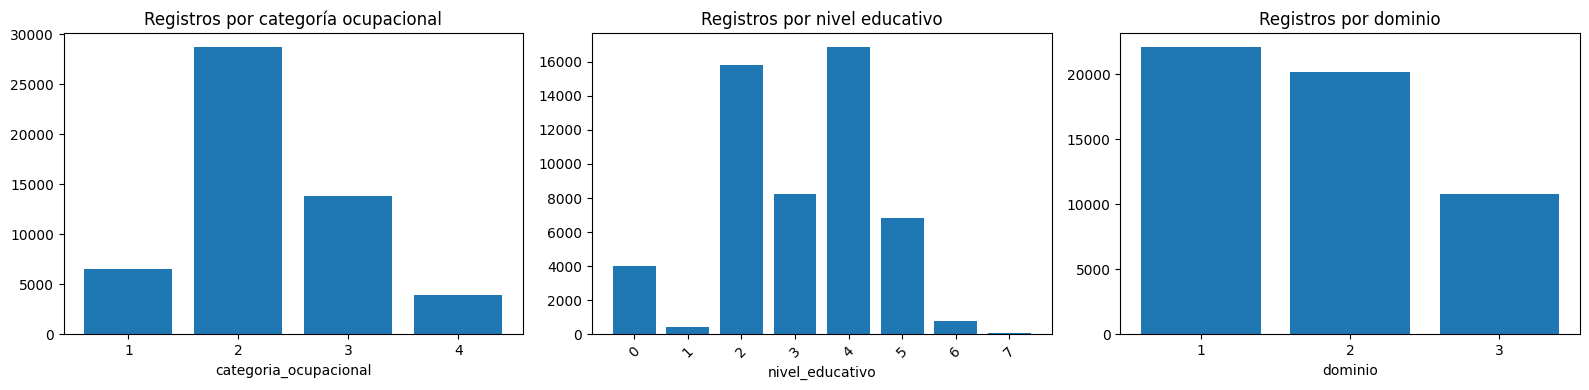

In [14]:
# Distribuciones: se calculan como AGREGADOS sobre el conjunto completo (no la muestra)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

conteo_cat = (df_2025_analitico.groupBy("categoria_ocupacional").count()
              .orderBy("categoria_ocupacional").toPandas())
axes[0].bar(conteo_cat["categoria_ocupacional"], conteo_cat["count"])
axes[0].set_title("Registros por categoría ocupacional")
axes[0].set_xlabel("categoria_ocupacional")

conteo_edu = (df_2025_analitico.groupBy("nivel_educativo").count()
              .orderBy("nivel_educativo").toPandas())
axes[1].bar(conteo_edu["nivel_educativo"], conteo_edu["count"])
axes[1].set_title("Registros por nivel educativo")
axes[1].set_xlabel("nivel_educativo")
axes[1].tick_params(axis="x", rotation=45)

conteo_dom = (df_2025_analitico.groupBy("dominio").count()
              .orderBy("dominio").toPandas())
axes[2].bar(conteo_dom["dominio"], conteo_dom["count"])
axes[2].set_title("Registros por dominio")
axes[2].set_xlabel("dominio")

plt.tight_layout()
plt.show()


In [15]:
top_cat = conteo_cat.sort_values("count", ascending=False).iloc[0]
top_edu = conteo_edu.sort_values("count", ascending=False).iloc[0]
top_dom = conteo_dom.sort_values("count", ascending=False).iloc[0]
print("Interpretación:")
print(f"- La categoría ocupacional con más registros es {top_cat['categoria_ocupacional']} ({int(top_cat['count']):,}).")
print(f"- El nivel educativo con más registros es {top_edu['nivel_educativo']} ({int(top_edu['count']):,}).")
print(f"- El dominio con más registros es {top_dom['dominio']} ({int(top_dom['count']):,}).")
print("- Estas distribuciones ayudan a identificar grupos con poca muestra antes de interpretar comparaciones por categoría.")


Interpretación:
- La categoría ocupacional con más registros es 2 (28,702).
- El nivel educativo con más registros es 4 (16,851).
- El dominio con más registros es 1 (22,072).
- Estas distribuciones ayudan a identificar grupos con poca muestra antes de interpretar comparaciones por categoría.


### ¿El salario presenta una distribución simétrica o asimétrica? ¿Qué diferencia existe entre su media y su mediana?

Media: 3,421.68 | Mediana: 3,000.00 | Diferencia: 421.68


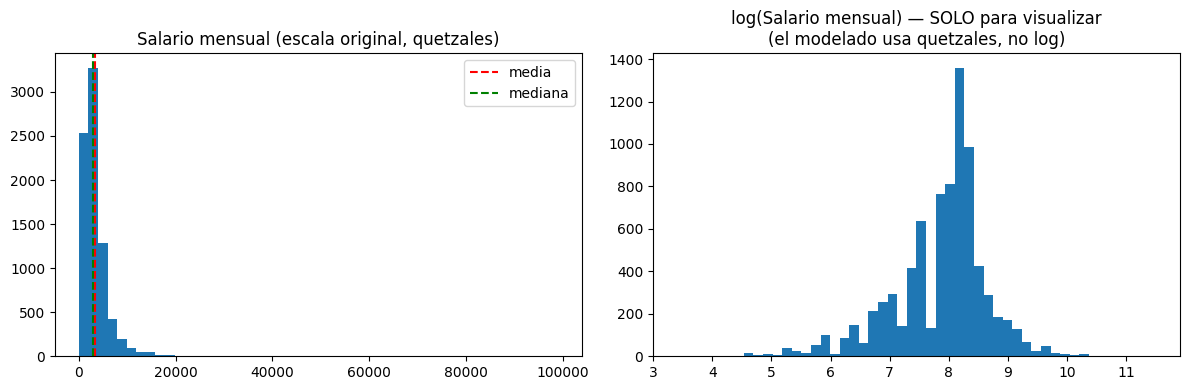

In [16]:
media_sal = resumen_2025.loc[resumen_2025["variable"] == "salario_mensual", "media"].values[0]
mediana_sal = resumen_2025.loc[resumen_2025["variable"] == "salario_mensual", "mediana"].values[0]
print(f"Media: {media_sal:,.2f} | Mediana: {mediana_sal:,.2f} | Diferencia: {media_sal - mediana_sal:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(muestra_2025_pdf["salario_mensual"], bins=50)
axes[0].axvline(media_sal, color="red", linestyle="--", label="media")
axes[0].axvline(mediana_sal, color="green", linestyle="--", label="mediana")
axes[0].set_title("Salario mensual (escala original, quetzales)")
axes[0].legend()

axes[1].hist(np.log(muestra_2025_pdf["salario_mensual"]), bins=50)
axes[1].set_title("log(Salario mensual) — SOLO para visualizar\n(el modelado usa quetzales, no log)")
plt.tight_layout()
plt.show()


In [17]:
sesgo = "a la derecha" if media_sal > mediana_sal else "a la izquierda o aproximadamente simétrica"
print("Interpretación:")
print(f"- La media salarial es Q{media_sal:,.2f} y la mediana es Q{mediana_sal:,.2f}.")
print(f"- La diferencia media - mediana es Q{media_sal - mediana_sal:,.2f}, lo que sugiere una distribución {sesgo}.")
print("- Si la media supera claramente a la mediana, pocos salarios altos elevan el promedio; por eso la mediana es útil para comparaciones entre grupos.")


Interpretación:
- La media salarial es Q3,421.68 y la mediana es Q3,000.00.
- La diferencia media - mediana es Q421.68, lo que sugiere una distribución a la derecha.
- Si la media supera claramente a la mediana, pocos salarios altos elevan el promedio; por eso la mediana es útil para comparaciones entre grupos.


### ¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?

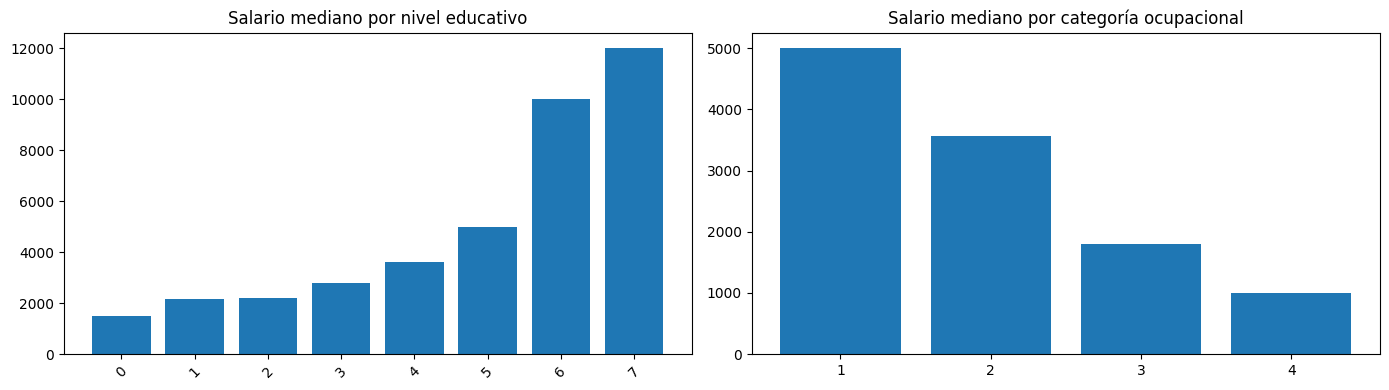

,nivel_educativo,salario_mediano,n
0,0,1500.0,3995
1,1,2160.0,459
2,2,2200.0,15822
3,3,2800.0,8249
4,4,3600.0,16851
5,5,5000.0,6818
6,6,10000.0,771
7,7,12000.0,60


,categoria_ocupacional,salario_mediano,n
0,1,5000.0,6575
1,2,3560.0,28702
2,3,1800.0,13842
3,4,1000.0,3906


In [18]:
mediana_por_edu = (df_2025_analitico.groupBy("nivel_educativo")
                    .agg(F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"),
                         F.count("*").alias("n"))
                    .orderBy("nivel_educativo").toPandas())

mediana_por_cat = (df_2025_analitico.groupBy("categoria_ocupacional")
                    .agg(F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"),
                         F.count("*").alias("n"))
                    .orderBy("categoria_ocupacional").toPandas())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(mediana_por_edu["nivel_educativo"], mediana_por_edu["salario_mediano"])
axes[0].set_title("Salario mediano por nivel educativo")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(mediana_por_cat["categoria_ocupacional"], mediana_por_cat["salario_mediano"])
axes[1].set_title("Salario mediano por categoría ocupacional")
plt.tight_layout()
plt.show()

display(mediana_por_edu)
display(mediana_por_cat)


In [19]:
edu_max = mediana_por_edu.sort_values("salario_mediano", ascending=False).iloc[0]
edu_min = mediana_por_edu.sort_values("salario_mediano", ascending=True).iloc[0]
cat_max = mediana_por_cat.sort_values("salario_mediano", ascending=False).iloc[0]
cat_min = mediana_por_cat.sort_values("salario_mediano", ascending=True).iloc[0]
print("Interpretación:")
print(f"- El mayor salario mediano por educación aparece en nivel {edu_max['nivel_educativo']} (Q{edu_max['salario_mediano']:,.2f}; n={int(edu_max['n']):,}).")
print(f"- El menor salario mediano por educación aparece en nivel {edu_min['nivel_educativo']} (Q{edu_min['salario_mediano']:,.2f}; n={int(edu_min['n']):,}).")
print(f"- Por categoría ocupacional, la mediana más alta es {cat_max['categoria_ocupacional']} (Q{cat_max['salario_mediano']:,.2f}; n={int(cat_max['n']):,}) y la más baja es {cat_min['categoria_ocupacional']} (Q{cat_min['salario_mediano']:,.2f}; n={int(cat_min['n']):,}).")
print("- Las diferencias deben leerse junto con n: grupos pequeños producen medianas menos estables.")


Interpretación:
- El mayor salario mediano por educación aparece en nivel 7 (Q12,000.00; n=60).
- El menor salario mediano por educación aparece en nivel 0 (Q1,500.00; n=3,995).
- Por categoría ocupacional, la mediana más alta es 1 (Q5,000.00; n=6,575) y la más baja es 4 (Q1,000.00; n=3,906).
- Las diferencias deben leerse junto con n: grupos pequeños producen medianas menos estables.


### ¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?

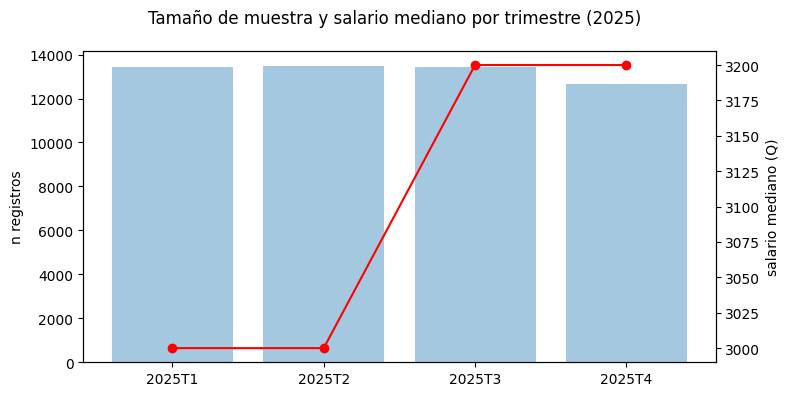

,periodo_archivo,n_registros,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


In [20]:
por_trimestre = (df_2025_analitico.groupBy("periodo_archivo")
                  .agg(F.count("*").alias("n_registros"),
                       F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"))
                  .orderBy("periodo_archivo").toPandas())

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(por_trimestre["periodo_archivo"], por_trimestre["n_registros"], alpha=0.4, label="n registros")
ax1.set_ylabel("n registros")
ax2 = ax1.twinx()
ax2.plot(por_trimestre["periodo_archivo"], por_trimestre["salario_mediano"], color="red", marker="o", label="salario mediano")
ax2.set_ylabel("salario mediano (Q)")
fig.suptitle("Tamaño de muestra y salario mediano por trimestre (2025)")
plt.tight_layout()
plt.show()

por_trimestre


In [21]:
n_min = por_trimestre["n_registros"].min()
n_max = por_trimestre["n_registros"].max()
sal_ini = por_trimestre.iloc[0]["salario_mediano"]
sal_fin = por_trimestre.iloc[-1]["salario_mediano"]
direccion = "aumenta" if sal_fin > sal_ini else "disminuye" if sal_fin < sal_ini else "se mantiene igual"
print("Interpretación:")
print(f"- La muestra analítica por trimestre varía entre {int(n_min):,} y {int(n_max):,} registros.")
print(f"- Entre el primer y el último trimestre de 2025, el salario mediano {direccion}: Q{sal_ini:,.2f} -> Q{sal_fin:,.2f}.")
print("- La interpretación debe centrarse en cambios descriptivos de los registros analizados, no en estimaciones oficiales de la población.")


Interpretación:
- La muestra analítica por trimestre varía entre 12,664 y 13,492 registros.
- Entre el primer y el último trimestre de 2025, el salario mediano aumenta: Q3,000.00 -> Q3,200.00.
- La interpretación debe centrarse en cambios descriptivos de los registros analizados, no en estimaciones oficiales de la población.


## 3. Relaciones entre variables numéricas — (5 pts)

Se calcula la correlación de Pearson entre `salario_mensual`, `edad`, `antiguedad` y
`horas_semanales` usando `VectorAssembler` + `Correlation.corr` de `pyspark.ml.stat`,
sobre **todos los registros elegibles de 2025** (sin muestreo).


In [22]:
CORR_COLS = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

df_corr_input = df_2025_analitico.select(*CORR_COLS).na.drop()

va_corr = VectorAssembler(inputCols=CORR_COLS, outputCol="features_corr")
vdf_corr = va_corr.transform(df_corr_input)

corr_matrix = Correlation.corr(vdf_corr, "features_corr", "pearson").head()[0].toArray()
corr_pdf = pd.DataFrame(corr_matrix, index=CORR_COLS, columns=CORR_COLS)
corr_pdf



[Stage 182:======>                                                (4 + 10) / 32]



,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000000,0.147249,0.179574,0.075665
edad,0.147249,1.000000,0.486713,-0.105378
antiguedad,0.179574,0.486713,1.000000,-0.062256
horas_semanales,0.075665,-0.105378,-0.062256,1.000000


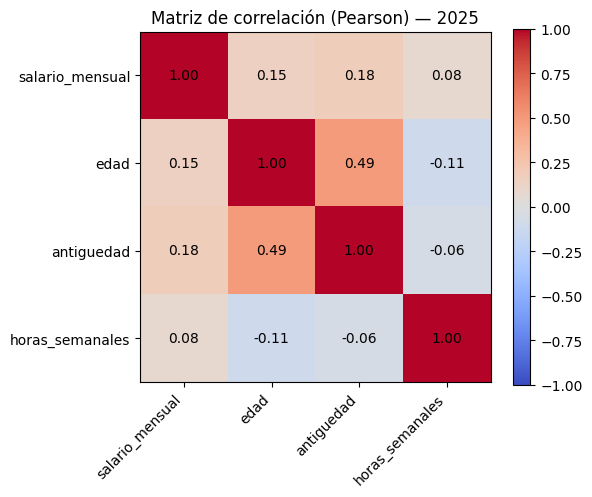

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(CORR_COLS))); ax.set_xticklabels(CORR_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(CORR_COLS))); ax.set_yticklabels(CORR_COLS)
for i in range(len(CORR_COLS)):
    for j in range(len(CORR_COLS)):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center", color="black")
ax.set_title("Matriz de correlación (Pearson) — 2025")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### Respuestas — Ejercicio 3

In [24]:
corr_salario = corr_pdf.loc["salario_mensual", ["edad", "antiguedad", "horas_semanales"]]
var_mayor = corr_salario.abs().idxmax()
valor_mayor = corr_salario[var_mayor]
corr_edad_ant = corr_pdf.loc["edad", "antiguedad"]
def fuerza_corr(r):
    ar = abs(r)
    if ar < 0.3:
        return "débil"
    if ar < 0.7:
        return "moderada"
    return "fuerte"
print("¿Qué variables presentan mayor asociación lineal con el salario?")
print(f"- La mayor asociación lineal absoluta con salario_mensual es {var_mayor}: r={valor_mayor:.3f} ({fuerza_corr(valor_mayor)}).")
print("- Estas correlaciones describen asociación lineal, no causalidad.")
print("\n¿Existe relación entre edad y antigüedad?")
print(f"- corr(edad, antiguedad) = {corr_edad_ant:.3f} ({fuerza_corr(corr_edad_ant)}).")
print("- Una relación positiva es esperable porque personas de mayor edad han tenido más tiempo para acumular antigüedad, aunque no determina el puesto actual.")


¿Qué variables presentan mayor asociación lineal con el salario?
- La mayor asociación lineal absoluta con salario_mensual es antiguedad: r=0.180 (débil).
- Estas correlaciones describen asociación lineal, no causalidad.

¿Existe relación entre edad y antigüedad?
- corr(edad, antiguedad) = 0.487 (moderada).
- Una relación positiva es esperable porque personas de mayor edad han tenido más tiempo para acumular antigüedad, aunque no determina el puesto actual.


## 4. Segmentación de perfiles mediante KMeans — (10 pts)

**Variables de clustering:** `edad`, `antiguedad`, `horas_semanales`.

**¿Vale la pena incluir salario?** Se prueba también una variante que incluye
`salario_mensual` para decidir, como equipo, si aporta separación adicional a los perfiles
o si domina la solución por su escala/asimetría (aun estandarizando, su alta dispersión y
cola larga puede hacer que los clusters terminen definidos casi exclusivamente por nivel de
ingreso en vez de por el perfil laboral/demográfico). La decisión final y su justificación
se documentan después de comparar ambas variantes.

Todas las variables se estandarizan (media 0, desviación 1) con `StandardScaler` antes de
correr `KMeans`, para que ninguna domine por su escala.


In [25]:
CLUSTER_COLS_BASE = ["edad", "antiguedad", "horas_semanales"]
CLUSTER_COLS_CON_SALARIO = CLUSTER_COLS_BASE + ["salario_mensual"]
CLUSTER_META_COLS = ["nivel_educativo", "categoria_ocupacional", "dominio", "salario_mensual"]

def preparar_features_cluster(sdf, cols):
    base_cols = list(dict.fromkeys(cols + CLUSTER_META_COLS))
    d = sdf.select(*base_cols).na.drop(subset=cols)
    va = VectorAssembler(inputCols=cols, outputCol="features_raw")
    d = va.transform(d)
    scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled",
                             withMean=True, withStd=True)
    scaler_model = scaler.fit(d)
    return scaler_model.transform(d)

def evaluar_k(d, variante, cols, ks=(2, 3, 4, 5)):
    resultados = []
    evaluator = ClusteringEvaluator(featuresCol="features_scaled", predictionCol="cluster")
    total = d.count()
    for k in ks:
        km = KMeans(featuresCol="features_scaled", predictionCol="cluster", k=k, seed=SEED)
        modelo = km.fit(d)
        pred = modelo.transform(d).persist()
        tamanos = pred.groupBy("cluster").count().toPandas()
        min_frac = tamanos["count"].min() / total
        resultados.append({
            "variante": variante, "k": k, "cols": cols, "silhouette": evaluator.evaluate(pred),
            "min_frac_cluster": min_frac, "modelo": modelo, "pred": pred
        })
    return resultados

data_A = preparar_features_cluster(df_2025_analitico, CLUSTER_COLS_BASE)
data_B = preparar_features_cluster(df_2025_analitico, CLUSTER_COLS_CON_SALARIO)
resultados_cluster = (
    evaluar_k(data_A, "sin_salario", CLUSTER_COLS_BASE) +
    evaluar_k(data_B, "con_salario", CLUSTER_COLS_CON_SALARIO)
)
comparacion_k = pd.DataFrame([
    {"variante": r["variante"], "k": r["k"], "silhouette": r["silhouette"],
     "min_frac_cluster": r["min_frac_cluster"]}
    for r in resultados_cluster
])
comparacion_k.sort_values(["silhouette", "min_frac_cluster"], ascending=False)


,variante,k,silhouette,min_frac_cluster
0,sin_salario,2,0.554736,0.275078
4,con_salario,2,0.514579,0.270306
5,con_salario,3,0.488785,0.056124
2,sin_salario,4,0.476467,0.129411
1,sin_salario,3,0.471622,0.190570
3,sin_salario,5,0.414598,0.069703
6,con_salario,4,0.398579,0.042131
7,con_salario,5,0.380517,0.018520


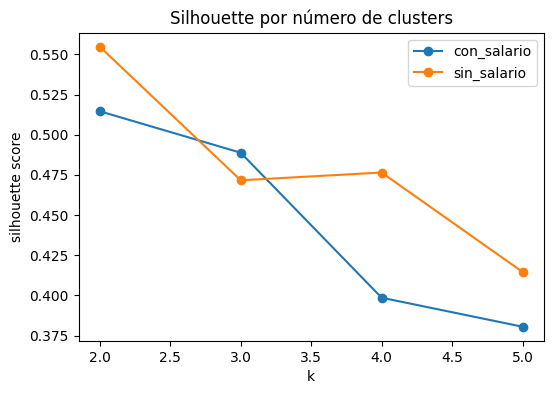

In [26]:
plt.figure(figsize=(6, 4))
for variante, g in comparacion_k.sort_values("k").groupby("variante"):
    plt.plot(g["k"], g["silhouette"], marker="o", label=variante)
plt.xlabel("k"); plt.ylabel("silhouette score")
plt.title("Silhouette por número de clusters")
plt.legend()
plt.show()


**Criterio de selección del equipo:** se elige el modelo con mayor `silhouette score`
entre las alternativas con clusters de tamaño razonable. Como regla operativa, se exige
que el cluster más pequeño tenga al menos 5% de los registros; si ninguna alternativa
cumple, se toma la mejor puntuación y se documenta la limitación. La comparación incluye
una variante sin salario y otra con salario para evaluar si el ingreso mejora la separación
o domina artificialmente los perfiles.

In [27]:
MIN_FRAC_CLUSTER = 0.05
candidatos = comparacion_k[comparacion_k["min_frac_cluster"] >= MIN_FRAC_CLUSTER]
if candidatos.empty:
    candidatos = comparacion_k
idx_mejor = candidatos["silhouette"].idxmax()
fila_mejor = comparacion_k.loc[idx_mejor]
mejor_resultado = next(
    r for r in resultados_cluster
    if r["variante"] == fila_mejor["variante"] and r["k"] == int(fila_mejor["k"])
)
MEJOR_VARIANTE = mejor_resultado["variante"]
MEJOR_K = mejor_resultado["k"]
cols_perfil = mejor_resultado["cols"]
pred_final = mejor_resultado["pred"]
print(
    f"Modelo seleccionado: {MEJOR_VARIANTE}, k={MEJOR_K}, "
    f"silhouette={mejor_resultado['silhouette']:.4f}, "
    f"cluster mínimo={mejor_resultado['min_frac_cluster']:.1%}"
)


Modelo seleccionado: sin_salario, k=2, silhouette=0.5547, cluster mínimo=27.5%


In [28]:
# --- Perfil de cada cluster: medias de las variables numéricas + tamaño ---
perfil_num = (pred_final.groupBy("cluster")
              .agg(F.count("*").alias("n"),
                   *[F.mean(c).alias(f"media_{c}") for c in cols_perfil])
              .orderBy("cluster").toPandas())
perfil_num


,cluster,n,media_edad,media_antiguedad,media_horas_semanales
0,0,14586,51.285822,13.818096,41.305156
1,1,38439,29.079060,2.424779,48.205546


In [29]:
# --- Composición categórica y salario por cluster para enriquecer cada perfil ---
pred_con_categoricas = pred_final

composicion_edu = (pred_con_categoricas.groupBy("cluster", "nivel_educativo").count()
                    .orderBy("cluster", "nivel_educativo").toPandas())
composicion_ocup = (pred_con_categoricas.groupBy("cluster", "categoria_ocupacional").count()
                    .orderBy("cluster", "categoria_ocupacional").toPandas())
salario_por_cluster = (pred_con_categoricas.groupBy("cluster")
                        .agg(F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"),
                             F.count("*").alias("n"))
                        .orderBy("cluster").toPandas())
display(composicion_edu)
display(composicion_ocup)
display(salario_por_cluster)


,cluster,nivel_educativo,count
0,0,0,2114
1,0,1,168
2,0,2,4742
3,0,3,1393
4,0,4,3288
5,0,5,2488
6,0,6,345
7,0,7,48
8,1,0,1881
9,1,1,291


,cluster,categoria_ocupacional,count
0,0,1,3429
1,0,2,6204
2,0,3,3546
3,0,4,1407
4,1,1,3146
5,1,2,22498
6,1,3,10296
7,1,4,2499


,cluster,salario_mediano,n
0,0,3466.0,14586
1,1,3000.0,38439


### Descripción de los clusters

In [30]:
perfil_desc = perfil_num.merge(salario_por_cluster[["cluster", "salario_mediano"]], on="cluster", how="left")
for _, row in perfil_desc.iterrows():
    partes = [
        f"edad media={row['media_edad']:.1f}",
        f"antigüedad media={row['media_antiguedad']:.1f} años",
        f"horas semanales medias={row['media_horas_semanales']:.1f}",
        f"salario mediano=Q{row['salario_mediano']:,.2f}",
        f"n={int(row['n']):,}",
    ]
    if "media_salario_mensual" in row.index:
        partes.insert(3, f"salario medio=Q{row['media_salario_mensual']:,.2f}")
    print(f"Cluster {int(row['cluster'])}: " + "; ".join(partes) + ".")
print("\nNota: salario_mensual se incluye como variable de clustering solo si la variante seleccionada fue con_salario; en caso contrario, se usa únicamente para describir los perfiles.")


Cluster 0: edad media=51.3; antigüedad media=13.8 años; horas semanales medias=41.3; salario mediano=Q3,466.00; n=14,586.
Cluster 1: edad media=29.1; antigüedad media=2.4 años; horas semanales medias=48.2; salario mediano=Q3,000.00; n=38,439.

Nota: salario_mensual se incluye como variable de clustering solo si la variante seleccionada fue con_salario; en caso contrario, se usa únicamente para describir los perfiles.


---
## 5. Pipeline de regresión lineal — (20 pts)

Se estima `salario_mensual` usando exactamente los seis predictores indicados en el enunciado: `edad`, `antiguedad`, `horas_semanales`, `nivel_educativo`, `categoria_ocupacional` y `dominio`.

Para evitar fuga de información, los transformadores (`StringIndexer`, `OneHotEncoder`, `StandardScaler`) y el modelo se ajustan exclusivamente con el conjunto de entrenamiento. Se usa `2025T1`–`2025T3` para entrenamiento y `2025T4` para validación; `2026T1` queda reservado para la evaluación final del Ejercicio 7.


In [31]:
PREDICTORES_NUM = ["edad", "antiguedad", "horas_semanales"]
PREDICTORES_CAT = ["nivel_educativo", "categoria_ocupacional", "dominio"]
TARGET = "salario_mensual"

train_periodos = ["2025T1", "2025T2", "2025T3"]
valid_periodos = ["2025T4"]

cols_modelo = [TARGET] + PREDICTORES_NUM + PREDICTORES_CAT + ["periodo_archivo"]
df_train_lr = (df_2025_analitico
               .filter(F.col("periodo_archivo").isin(train_periodos))
               .select(*cols_modelo)
               .na.drop(subset=[TARGET] + PREDICTORES_NUM)
               .persist())
df_valid_lr = (df_2025_analitico
               .filter(F.col("periodo_archivo").isin(valid_periodos))
               .select(*cols_modelo)
               .na.drop(subset=[TARGET] + PREDICTORES_NUM)
               .persist())

print(f"Registros entrenamiento LR: {df_train_lr.count():,}")
print(f"Registros validación LR: {df_valid_lr.count():,}")


Registros entrenamiento LR: 40,361


Registros validación LR: 12,664


### Modelo de referencia

El modelo de referencia predice siempre el salario promedio observado en entrenamiento. La regresión lineal debe compararse contra este punto de partida: si no reduce MAE/RMSE o no mejora R², sus predictores no estarían aportando capacidad predictiva útil frente a una regla constante.


In [32]:
def evaluar_regresion(predicciones, etiqueta):
    evaluadores = {
        "MAE": RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="mae"),
        "RMSE": RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="rmse"),
        "R2": RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="r2"),
    }
    return {"modelo": etiqueta, **{m: ev.evaluate(predicciones) for m, ev in evaluadores.items()}}

salario_medio_train = df_train_lr.agg(F.mean(TARGET).alias("media")).first()["media"]
pred_ref_valid = df_valid_lr.withColumn("prediction", F.lit(float(salario_medio_train)))
metricas_ref = evaluar_regresion(pred_ref_valid, "Referencia: media train")
metricas_ref


{'modelo': 'Referencia: media train',
 'MAE': 1672.502605643495,
 'RMSE': 2889.571432265959,
 'R2': -0.0031316038524940026}

### Pipeline y regularización

El pipeline codifica las variables categóricas con `StringIndexer` + `OneHotEncoder`, combina las variables numéricas y dummies con `VectorAssembler`, estandariza los predictores con `StandardScaler` y entrena `LinearRegression`. Como se usa `StandardScaler`, se desactiva la estandarización interna del estimador para no aplicar ambos mecanismos.


In [33]:
def construir_pipeline_lr(reg_param, elastic_net_param):
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in PREDICTORES_CAT
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_oh", handleInvalid="keep")
        for c in PREDICTORES_CAT
    ]
    assembler = VectorAssembler(
        inputCols=PREDICTORES_NUM + [f"{c}_oh" for c in PREDICTORES_CAT],
        outputCol="features_sin_escalar",
        handleInvalid="keep",
    )
    scaler = StandardScaler(
        inputCol="features_sin_escalar",
        outputCol="features",
        withMean=True,
        withStd=True,
    )
    lr = LinearRegression(
        featuresCol="features",
        labelCol=TARGET,
        predictionCol="prediction",
        regParam=reg_param,
        elasticNetParam=elastic_net_param,
        standardization=False,
    )
    return Pipeline(stages=indexers + encoders + [assembler, scaler, lr])

configuraciones_lr = [
    {"nombre": "LR sin regularización", "regParam": 0.0, "elasticNetParam": 0.0},
    {"nombre": "LR Ridge", "regParam": 0.1, "elasticNetParam": 0.0},
    {"nombre": "LR ElasticNet", "regParam": 0.1, "elasticNetParam": 0.5},
]

resultados_lr = []
modelos_lr = {}
for cfg in configuraciones_lr:
    pipeline = construir_pipeline_lr(cfg["regParam"], cfg["elasticNetParam"])
    modelo = pipeline.fit(df_train_lr)
    pred_valid = modelo.transform(df_valid_lr).persist()
    metricas = evaluar_regresion(pred_valid, cfg["nombre"])
    resultados_lr.append({**cfg, **metricas})
    modelos_lr[cfg["nombre"]] = modelo

comparacion_lr = pd.DataFrame([metricas_ref] + resultados_lr)
comparacion_lr = comparacion_lr.sort_values("RMSE")
comparacion_lr


,modelo,MAE,RMSE,R2,nombre,regParam,elasticNetParam
1,LR sin regularización,1210.137480,2186.419579,0.425675,LR sin regularización,0.0,0.0
2,LR Ridge,1210.132743,2186.420859,0.425674,LR Ridge,0.1,0.0
3,LR ElasticNet,1210.107022,2186.424785,0.425672,LR ElasticNet,0.1,0.5
0,Referencia: media train,1672.502606,2889.571432,-0.003132,NaN,NaN,NaN


In [34]:
solo_lr = pd.DataFrame(resultados_lr).sort_values("RMSE")
mejor_cfg_lr = solo_lr.iloc[0].to_dict()
MEJOR_LR_NOMBRE = mejor_cfg_lr["nombre"]
mejor_modelo_lr = modelos_lr[MEJOR_LR_NOMBRE]

print(f"Mejor configuración LR: {MEJOR_LR_NOMBRE}")
print(f"regParam={mejor_cfg_lr['regParam']} | elasticNetParam={mejor_cfg_lr['elasticNetParam']}")
print(f"Validación: MAE={mejor_cfg_lr['MAE']:,.2f} | RMSE={mejor_cfg_lr['RMSE']:,.2f} | R2={mejor_cfg_lr['R2']:.4f}")
print(f"Referencia: MAE={metricas_ref['MAE']:,.2f} | RMSE={metricas_ref['RMSE']:,.2f} | R2={metricas_ref['R2']:.4f}")


Mejor configuración LR: LR sin regularización
regParam=0.0 | elasticNetParam=0.0
Validación: MAE=1,210.14 | RMSE=2,186.42 | R2=0.4257
Referencia: MAE=1,672.50 | RMSE=2,889.57 | R2=-0.0031


In [35]:
print("Interpretación:")
if mejor_cfg_lr["RMSE"] < metricas_ref["RMSE"]:
    print("- La mejor regresión lineal reduce el RMSE frente al modelo de referencia, por lo que los seis predictores aportan información predictiva en validación.")
else:
    print("- La mejor regresión lineal no mejora el RMSE del modelo de referencia; esto sugiere baja capacidad predictiva lineal con estas variables.")
print(f"- El MAE indica que, en promedio absoluto, las predicciones se alejan Q{mejor_cfg_lr['MAE']:,.2f} del salario observado en 2025T4.")
print(f"- El RMSE (Q{mejor_cfg_lr['RMSE']:,.2f}) penaliza más los errores grandes, relevantes porque el salario suele tener cola derecha.")
print(f"- El R2 de validación ({mejor_cfg_lr['R2']:.4f}) resume la proporción de variabilidad explicada frente a una predicción constante.")
print("- Estos resultados son predictivos y no deben interpretarse como efectos causales de educación, dominio u ocupación sobre salario.")


Interpretación:
- La mejor regresión lineal reduce el RMSE frente al modelo de referencia, por lo que los seis predictores aportan información predictiva en validación.
- El MAE indica que, en promedio absoluto, las predicciones se alejan Q1,210.14 del salario observado en 2025T4.
- El RMSE (Q2,186.42) penaliza más los errores grandes, relevantes porque el salario suele tener cola derecha.
- El R2 de validación (0.4257) resume la proporción de variabilidad explicada frente a una predicción constante.
- Estos resultados son predictivos y no deben interpretarse como efectos causales de educación, dominio u ocupación sobre salario.


In [36]:
ruta_mejor_lr = f"{MODEL_DIR}/mejor_modelo_lr"
mejor_modelo_lr.write().overwrite().save(ruta_mejor_lr)
print("Mejor modelo de regresión lineal guardado en:", ruta_mejor_lr)


Mejor modelo de regresión lineal guardado en: /Users/karentoledo/Documents/GitHub/Lab7-Spark-DS/models/mejor_modelo_lr


---
## 6. Pipeline de Random Forest — (20 pts)

Se construye un segundo pipeline supervisado con los mismos conjuntos de entrenamiento y validación del Ejercicio 5. El modelo usa los mismos seis predictores y la misma codificación categórica (`StringIndexer` + `OneHotEncoder`), pero no estandariza las variables porque los árboles de decisión no dependen de distancias ni de escalas lineales.

Todos los componentes del pipeline se ajustan exclusivamente con `df_train_lr` (`2025T1`–`2025T3`). La validación se realiza en `df_valid_lr` (`2025T4`) y `2026T1` sigue reservado para el Ejercicio 7.


In [37]:
def construir_pipeline_rf(num_trees, max_depth):
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx_rf", handleInvalid="keep")
        for c in PREDICTORES_CAT
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx_rf", outputCol=f"{c}_oh_rf", handleInvalid="keep")
        for c in PREDICTORES_CAT
    ]
    assembler = VectorAssembler(
        inputCols=PREDICTORES_NUM + [f"{c}_oh_rf" for c in PREDICTORES_CAT],
        outputCol="features_rf",
        handleInvalid="keep",
    )
    rf = RandomForestRegressor(
        featuresCol="features_rf",
        labelCol=TARGET,
        predictionCol="prediction",
        numTrees=num_trees,
        maxDepth=max_depth,
        seed=SEED,
    )
    return Pipeline(stages=indexers + encoders + [assembler, rf])

configuraciones_rf = [
    {"nombre": "RF 50 árboles profundidad 5", "numTrees": 50, "maxDepth": 5},
    {"nombre": "RF 100 árboles profundidad 5", "numTrees": 100, "maxDepth": 5},
    {"nombre": "RF 100 árboles profundidad 8", "numTrees": 100, "maxDepth": 8},
]

resultados_rf = []
modelos_rf = {}
for cfg in configuraciones_rf:
    pipeline = construir_pipeline_rf(cfg["numTrees"], cfg["maxDepth"])
    modelo = pipeline.fit(df_train_lr)
    pred_valid = modelo.transform(df_valid_lr).persist()
    metricas = evaluar_regresion(pred_valid, cfg["nombre"])
    resultados_rf.append({**cfg, **metricas})
    modelos_rf[cfg["nombre"]] = modelo

comparacion_rf = pd.DataFrame(resultados_rf).sort_values("RMSE")
comparacion_rf



[Stage 853:==============================>                        (18 + 8) / 32]




[Stage 925:====================>                                  (12 + 8) / 32]




[Stage 927:=============================>                         (17 + 8) / 32]



,nombre,numTrees,maxDepth,modelo,MAE,RMSE,R2
2,RF 100 árboles profundidad 8,100,8,RF 100 árboles profundidad 8,1093.744981,2037.741512,0.501128
0,RF 50 árboles profundidad 5,50,5,RF 50 árboles profundidad 5,1159.178507,2161.297423,0.438797
1,RF 100 árboles profundidad 5,100,5,RF 100 árboles profundidad 5,1152.839331,2165.144894,0.436797


In [38]:
mejor_cfg_rf = comparacion_rf.iloc[0].to_dict()
MEJOR_RF_NOMBRE = mejor_cfg_rf["modelo"]
mejor_modelo_rf = modelos_rf[MEJOR_RF_NOMBRE]

print(f"Mejor configuración RF: {MEJOR_RF_NOMBRE}")
print(f"numTrees={int(mejor_cfg_rf['numTrees'])} | maxDepth={int(mejor_cfg_rf['maxDepth'])}")
print(f"Validación: MAE={mejor_cfg_rf['MAE']:,.2f} | RMSE={mejor_cfg_rf['RMSE']:,.2f} | R2={mejor_cfg_rf['R2']:.4f}")


Mejor configuración RF: RF 100 árboles profundidad 8
numTrees=100 | maxDepth=8
Validación: MAE=1,093.74 | RMSE=2,037.74 | R2=0.5011


### Comparación con regresión lineal y referencia

Se comparan las mejores configuraciones de Random Forest y regresión lineal contra el modelo de referencia. El criterio principal de selección es menor RMSE en validación, porque penaliza más los errores grandes y es sensible a salarios extremos, que el enunciado pide conservar.


In [39]:
resumen_validacion_modelos = pd.DataFrame([
    metricas_ref,
    {"modelo": f"Mejor LR: {MEJOR_LR_NOMBRE}", "MAE": mejor_cfg_lr["MAE"], "RMSE": mejor_cfg_lr["RMSE"], "R2": mejor_cfg_lr["R2"]},
    {"modelo": f"Mejor RF: {MEJOR_RF_NOMBRE}", "MAE": mejor_cfg_rf["MAE"], "RMSE": mejor_cfg_rf["RMSE"], "R2": mejor_cfg_rf["R2"]},
]).sort_values("RMSE")
resumen_validacion_modelos


,modelo,MAE,RMSE,R2
2,Mejor RF: RF 100 árboles profundidad 8,1093.744981,2037.741512,0.501128
1,Mejor LR: LR sin regularización,1210.137480,2186.419579,0.425675
0,Referencia: media train,1672.502606,2889.571432,-0.003132


In [40]:
mejor_global_validacion = resumen_validacion_modelos.iloc[0]
print("Interpretación:")
print(f"- El mejor resultado de validación según RMSE es: {mejor_global_validacion['modelo']} (RMSE=Q{mejor_global_validacion['RMSE']:,.2f}).")
if mejor_cfg_rf["RMSE"] < mejor_cfg_lr["RMSE"]:
    print("- Random Forest supera a la regresión lineal en RMSE de validación. Esto puede deberse a que captura relaciones no lineales e interacciones entre educación, ocupación, dominio, edad, antigüedad y horas.")
elif mejor_cfg_rf["RMSE"] > mejor_cfg_lr["RMSE"]:
    print("- La regresión lineal supera a Random Forest en RMSE de validación. Esto puede ocurrir si la señal predictiva principal es aproximadamente lineal o si el bosque no generaliza mejor con estas variables.")
else:
    print("- Random Forest y regresión lineal obtienen el mismo RMSE de validación con las configuraciones probadas.")
print(f"- Frente a la referencia, el mejor RF cambia el RMSE de Q{metricas_ref['RMSE']:,.2f} a Q{mejor_cfg_rf['RMSE']:,.2f}.")
print("- La comparación sigue siendo no causal: mide capacidad predictiva sobre 2025T4, no efectos económicos estructurales.")


Interpretación:
- El mejor resultado de validación según RMSE es: Mejor RF: RF 100 árboles profundidad 8 (RMSE=Q2,037.74).
- Random Forest supera a la regresión lineal en RMSE de validación. Esto puede deberse a que captura relaciones no lineales e interacciones entre educación, ocupación, dominio, edad, antigüedad y horas.
- Frente a la referencia, el mejor RF cambia el RMSE de Q2,889.57 a Q2,037.74.
- La comparación sigue siendo no causal: mide capacidad predictiva sobre 2025T4, no efectos económicos estructurales.


In [41]:
ruta_mejor_rf = f"{MODEL_DIR}/mejor_modelo_rf"
mejor_modelo_rf.write().overwrite().save(ruta_mejor_rf)
print("Mejor modelo Random Forest guardado en:", ruta_mejor_rf)


Mejor modelo Random Forest guardado en: /Users/karentoledo/Documents/GitHub/Lab7-Spark-DS/models/mejor_modelo_rf


---
## 7. Entrenamiento final y evaluación en 2026 — (20 pts)

Con las configuraciones seleccionadas en validación para regresión lineal y Random Forest, se ajustan modelos finales usando todos los registros analíticos de 2025. Luego se generan predicciones sobre `2026T1`, aplicando las mismas reglas de preparación ya definidas.

Ambos modelos se evalúan sobre exactamente los mismos registros elegibles de prueba y se comparan con un modelo de referencia que predice la media salarial del conjunto final de entrenamiento 2025.


In [42]:
cols_modelo_final = [TARGET] + PREDICTORES_NUM + PREDICTORES_CAT + ["periodo_archivo"]

df_train_final_2025 = (df_2025_analitico
                       .select(*cols_modelo_final)
                       .na.drop(subset=[TARGET] + PREDICTORES_NUM)
                       .persist())
df_test_2026 = (df_2026_analitico
                .select(*cols_modelo_final)
                .na.drop(subset=[TARGET] + PREDICTORES_NUM)
                .persist())

n_train_final = df_train_final_2025.count()
n_test_2026 = df_test_2026.count()
print(f"Registros entrenamiento final 2025: {n_train_final:,}")
print(f"Registros prueba final 2026T1: {n_test_2026:,}")


Registros entrenamiento final 2025: 53,025
Registros prueba final 2026T1: 13,258


In [43]:
# Modelo de referencia final: predice la media salarial de todo 2025 analítico.
salario_medio_final_2025 = df_train_final_2025.agg(F.mean(TARGET).alias("media")).first()["media"]
pred_ref_2026 = df_test_2026.withColumn("prediction", F.lit(float(salario_medio_final_2025)))
metricas_ref_2026 = evaluar_regresion(pred_ref_2026, "Referencia 2026: media 2025")
metricas_ref_2026


{'modelo': 'Referencia 2026: media 2025',
 'MAE': 1718.0860053858758,
 'RMSE': 2871.42067731133,
 'R2': -0.002525217118245715}

### Ajuste final de los modelos

Se reusa la mejor configuración encontrada en validación para cada algoritmo, pero el ajuste se realiza ahora con todo 2025. El conjunto `2026T1` no participa en ningún ajuste; se usa únicamente para estimar desempeño fuera de muestra.


In [44]:
pipeline_lr_final = construir_pipeline_lr(
    reg_param=float(mejor_cfg_lr["regParam"]),
    elastic_net_param=float(mejor_cfg_lr["elasticNetParam"]),
)
modelo_lr_final_2025 = pipeline_lr_final.fit(df_train_final_2025)
pred_lr_2026 = modelo_lr_final_2025.transform(df_test_2026).persist()
metricas_lr_2026 = evaluar_regresion(pred_lr_2026, f"LR final 2026: {MEJOR_LR_NOMBRE}")

pipeline_rf_final = construir_pipeline_rf(
    num_trees=int(mejor_cfg_rf["numTrees"]),
    max_depth=int(mejor_cfg_rf["maxDepth"]),
)
modelo_rf_final_2025 = pipeline_rf_final.fit(df_train_final_2025)
pred_rf_2026 = modelo_rf_final_2025.transform(df_test_2026).persist()
metricas_rf_2026 = evaluar_regresion(pred_rf_2026, f"RF final 2026: {MEJOR_RF_NOMBRE}")

resumen_2026 = pd.DataFrame([metricas_ref_2026, metricas_lr_2026, metricas_rf_2026]).sort_values("RMSE")
resumen_2026



[Stage 1034:===========================>                          (16 + 8) / 32]




[Stage 1036:=>                                                     (1 + 9) / 32]




[Stage 1036:===========================>                          (16 + 8) / 32]



,modelo,MAE,RMSE,R2
2,RF final 2026: RF 100 árboles profundidad 8,1124.244568,2011.766489,0.507896
1,LR final 2026: LR sin regularización,1240.710547,2163.751703,0.430732
0,Referencia 2026: media 2025,1718.086005,2871.420677,-0.002525


In [45]:
print("Configuraciones finales evaluadas en 2026:")
print(f"- Regresión lineal: {MEJOR_LR_NOMBRE}; regParam={float(mejor_cfg_lr['regParam'])}; elasticNetParam={float(mejor_cfg_lr['elasticNetParam'])}")
print(f"- Random Forest: {MEJOR_RF_NOMBRE}; numTrees={int(mejor_cfg_rf['numTrees'])}; maxDepth={int(mejor_cfg_rf['maxDepth'])}")
print(f"- Registros de prueba usados por ambos modelos: {n_test_2026:,}")


Configuraciones finales evaluadas en 2026:
- Regresión lineal: LR sin regularización; regParam=0.0; elasticNetParam=0.0
- Random Forest: RF 100 árboles profundidad 8; numTrees=100; maxDepth=8
- Registros de prueba usados por ambos modelos: 13,258


In [46]:
mejor_2026 = resumen_2026.iloc[0]
print("Interpretación — evaluación final 2026:")
print(f"- El mejor desempeño en 2026 según RMSE es: {mejor_2026['modelo']} (RMSE=Q{mejor_2026['RMSE']:,.2f}).")
if metricas_rf_2026["RMSE"] < metricas_lr_2026["RMSE"]:
    print("- Random Forest generaliza mejor que la regresión lineal en la prueba final; su ventaja puede venir de capturar no linealidades e interacciones entre predictores.")
elif metricas_rf_2026["RMSE"] > metricas_lr_2026["RMSE"]:
    print("- La regresión lineal generaliza mejor que Random Forest en la prueba final; el modelo más simple puede estar evitando sobreajuste o capturando suficiente señal lineal.")
else:
    print("- Ambos algoritmos obtienen el mismo RMSE en la prueba final con las configuraciones seleccionadas.")
if mejor_2026["RMSE"] < metricas_ref_2026["RMSE"]:
    print("- El mejor modelo supera al referente de media salarial, por lo que las características observadas aportan información predictiva fuera de muestra.")
else:
    print("- Ningún modelo mejora al referente de media salarial en RMSE; esto indicaría baja capacidad predictiva fuera de muestra con estas variables.")
print("- La evaluación en 2026 mide desempeño predictivo, no relaciones causales ni recomendaciones salariales.")


Interpretación — evaluación final 2026:
- El mejor desempeño en 2026 según RMSE es: RF final 2026: RF 100 árboles profundidad 8 (RMSE=Q2,011.77).
- Random Forest generaliza mejor que la regresión lineal en la prueba final; su ventaja puede venir de capturar no linealidades e interacciones entre predictores.
- El mejor modelo supera al referente de media salarial, por lo que las características observadas aportan información predictiva fuera de muestra.
- La evaluación en 2026 mide desempeño predictivo, no relaciones causales ni recomendaciones salariales.


In [47]:
ruta_lr_final_2025 = f"{MODEL_DIR}/modelo_lr_final_2025"
ruta_rf_final_2025 = f"{MODEL_DIR}/modelo_rf_final_2025"
modelo_lr_final_2025.write().overwrite().save(ruta_lr_final_2025)
modelo_rf_final_2025.write().overwrite().save(ruta_rf_final_2025)
print("Modelo final LR guardado en:", ruta_lr_final_2025)
print("Modelo final RF guardado en:", ruta_rf_final_2025)


Modelo final LR guardado en: /Users/karentoledo/Documents/GitHub/Lab7-Spark-DS/models/modelo_lr_final_2025
Modelo final RF guardado en: /Users/karentoledo/Documents/GitHub/Lab7-Spark-DS/models/modelo_rf_final_2025


---
## 8. Visualización y análisis de errores — (15 pts)

Para evaluar el comportamiento de los modelos, se define el residuo como:

\[
\text{residuo} = \text{salario real} - \text{salario predicho}
\]

Por lo tanto:

- Un residuo positivo indica que el modelo subestimó el salario.
- Un residuo negativo indica que el modelo sobreestimó el salario.

Para comparar visualmente la regresión lineal y Random Forest se utiliza exactamente la
misma muestra aleatoria de hasta 5,000 registros de prueba. Las métricas por nivel educativo,
dominio y rango salarial se calculan utilizando todos los registros elegibles de 2026T1.

> Esta sección debe colocarse después de la Actividad 7, pues utiliza los modelos finales,
> las predicciones de 2026 y las variables creadas anteriormente.


In [ ]:
from IPython.display import Markdown

MAX_MUESTRA_ERRORES = 5000

# Se selecciona una sola muestra base para ambos modelos.
muestra_base_2026 = (
    df_test_2026
    .orderBy(F.rand(seed=SEED))
    .limit(MAX_MUESTRA_ERRORES)
    .cache()
)

# Los dos modelos predicen exactamente los mismos registros.
muestra_lr_spark = (
    modelo_lr_final_2025
    .transform(muestra_base_2026)
    .select(TARGET, "prediction", "nivel_educativo", "dominio")
    .withColumn("residuo", F.col(TARGET) - F.col("prediction"))
)

muestra_rf_spark = (
    modelo_rf_final_2025
    .transform(muestra_base_2026)
    .select(TARGET, "prediction", "nivel_educativo", "dominio")
    .withColumn("residuo", F.col(TARGET) - F.col("prediction"))
)

muestra_lr_pdf = muestra_lr_spark.toPandas()
muestra_rf_pdf = muestra_rf_spark.toPandas()

print(f"Registros utilizados en ambos análisis visuales: {len(muestra_lr_pdf):,}")


### 8.1 Salario real frente a salario predicho

La línea diagonal \(y=x\) representa una predicción perfecta. Los puntos por encima de la
línea corresponden a salarios subestimados y los puntos por debajo corresponden a salarios
sobreestimados.


In [ ]:
valores_limites = np.concatenate([
    muestra_lr_pdf[TARGET].to_numpy(),
    muestra_lr_pdf["prediction"].to_numpy(),
    muestra_rf_pdf[TARGET].to_numpy(),
    muestra_rf_pdf["prediction"].to_numpy()
])

limite_inferior = min(0, np.nanmin(valores_limites))
limite_superior = np.nanmax(valores_limites)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

modelos_grafica = [
    ("Regresión lineal", muestra_lr_pdf),
    ("Random Forest", muestra_rf_pdf)
]

for ax, (nombre, datos) in zip(axes, modelos_grafica):
    ax.scatter(
        datos[TARGET], datos["prediction"],
        alpha=0.30, s=15, color="#2374AB"
    )
    ax.plot(
        [limite_inferior, limite_superior],
        [limite_inferior, limite_superior],
        linestyle="--", color="red", linewidth=2,
        label="Predicción perfecta (y=x)"
    )
    ax.set_title(nombre)
    ax.set_xlabel("Salario mensual real (Q)")
    ax.set_ylabel("Salario mensual predicho (Q)")
    ax.grid(alpha=0.20)
    ax.legend()

plt.suptitle("Salario real frente a salario predicho — prueba 2026T1", fontsize=14)
plt.tight_layout()
plt.show()


### 8.2 Residuos frente al salario predicho

Un modelo sin errores sistemáticos debería mostrar residuos distribuidos aleatoriamente
alrededor de cero. Una concentración de residuos positivos en salarios altos indicaría que
el modelo tiende a subestimar esos salarios.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for ax, (nombre, datos) in zip(axes, modelos_grafica):
    ax.scatter(
        datos["prediction"], datos["residuo"],
        alpha=0.30, s=15, color="#E07A5F"
    )
    ax.axhline(
        y=0, linestyle="--", color="black", linewidth=2,
        label="Residuo igual a cero"
    )
    ax.set_title(nombre)
    ax.set_xlabel("Salario mensual predicho (Q)")
    ax.set_ylabel("Residuo: real - predicho (Q)")
    ax.grid(alpha=0.20)
    ax.legend()

plt.suptitle("Residuos frente al salario predicho — prueba 2026T1", fontsize=14)
plt.tight_layout()
plt.show()


### 8.3 MAE y error medio por nivel educativo y dominio

El MAE permite conocer la magnitud promedio del error sin considerar su dirección. El
error medio conserva el signo del residuo:

- Error medio positivo: el modelo tiende a subestimar.
- Error medio negativo: el modelo tiende a sobreestimar.

Estas métricas se calculan sobre todos los registros elegibles de 2026T1, no sobre la
muestra utilizada para las gráficas.


In [ ]:
def calcular_errores_por_grupo(predicciones, grupo, nombre_modelo):
    return (
        predicciones
        .withColumn("residuo", F.col(TARGET) - F.col("prediction"))
        .withColumn("error_absoluto", F.abs(F.col("residuo")))
        .groupBy(grupo)
        .agg(
            F.count("*").alias("n_observaciones"),
            F.avg("error_absoluto").alias("MAE"),
            F.avg("residuo").alias("error_medio")
        )
        .withColumn("modelo", F.lit(nombre_modelo))
        .select("modelo", grupo, "n_observaciones", "MAE", "error_medio")
        .orderBy(grupo)
    )


# Se utilizan las predicciones completas de 2026T1.
lr_por_educacion = calcular_errores_por_grupo(
    pred_lr_2026, "nivel_educativo", "Regresión lineal"
)
rf_por_educacion = calcular_errores_por_grupo(
    pred_rf_2026, "nivel_educativo", "Random Forest"
)
lr_por_dominio = calcular_errores_por_grupo(
    pred_lr_2026, "dominio", "Regresión lineal"
)
rf_por_dominio = calcular_errores_por_grupo(
    pred_rf_2026, "dominio", "Random Forest"
)

tabla_educacion = (
    lr_por_educacion
    .unionByName(rf_por_educacion)
    .orderBy("nivel_educativo", "modelo")
    .toPandas()
)

tabla_dominio = (
    lr_por_dominio
    .unionByName(rf_por_dominio)
    .orderBy("dominio", "modelo")
    .toPandas()
)

for columna in ["MAE", "error_medio"]:
    tabla_educacion[columna] = tabla_educacion[columna].round(2)
    tabla_dominio[columna] = tabla_dominio[columna].round(2)

print("Errores por nivel educativo:")
display(tabla_educacion)

print("\nErrores por dominio:")
display(tabla_dominio)


### 8.4 Percentiles salariales y comportamiento de los errores

Debido a que la distribución salarial presenta una cola derecha, el desempeño general puede
ocultar errores considerablemente mayores entre las personas con salarios altos. Por ello,
se calculan percentiles sobre todos los registros de prueba y se estudian los errores dentro
de diferentes rangos salariales.


In [ ]:
percentiles_solicitados = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

valores_percentiles = df_test_2026.approxQuantile(
    TARGET, percentiles_solicitados, 0.001
)

tabla_percentiles = pd.DataFrame({
    "percentil": ["P25", "P50", "P75", "P90", "P95", "P99"],
    "salario_mensual_Q": valores_percentiles
})
tabla_percentiles["salario_mensual_Q"] = (
    tabla_percentiles["salario_mensual_Q"].round(2)
)

display(tabla_percentiles)

p25, p50, p75, p90, p95, p99 = valores_percentiles

print(f"Mediana salarial de prueba: Q{p50:,.2f}")
print(f"El 5% de los salarios supera aproximadamente Q{p95:,.2f}.")
print(f"El 1% de los salarios supera aproximadamente Q{p99:,.2f}.")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Vista del salario original hasta P99 para observar mejor la distribución.
axes[0].hist(
    muestra_lr_pdf[TARGET], bins=50,
    color="#4C956C", edgecolor="white"
)
axes[0].axvline(p50, color="black", linestyle="--", label="P50")
axes[0].axvline(p95, color="red", linestyle="--", label="P95")
axes[0].set_xlim(0, p99)
axes[0].set_title("Distribución salarial hasta el percentil 99")
axes[0].set_xlabel("Salario mensual (Q)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].grid(alpha=0.20)

# Escala logarítmica únicamente para visualizar la cola derecha.
axes[1].hist(
    np.log10(muestra_lr_pdf[TARGET]), bins=50,
    color="#F2CC8F", edgecolor="white"
)
axes[1].set_title("Distribución salarial en escala logarítmica")
axes[1].set_xlabel("log10 del salario mensual")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.20)

plt.tight_layout()
plt.show()


In [ ]:
def agregar_rango_salarial(predicciones):
    return (
        predicciones
        .withColumn("residuo", F.col(TARGET) - F.col("prediction"))
        .withColumn("error_absoluto", F.abs(F.col("residuo")))
        .withColumn(
            "rango_salarial",
            F.when(F.col(TARGET) <= p50, "1. Hasta P50")
             .when(F.col(TARGET) <= p75, "2. P50-P75")
             .when(F.col(TARGET) <= p90, "3. P75-P90")
             .when(F.col(TARGET) <= p95, "4. P90-P95")
             .otherwise("5. Mayor que P95")
        )
    )


def errores_por_rango(predicciones, nombre_modelo):
    return (
        agregar_rango_salarial(predicciones)
        .groupBy("rango_salarial")
        .agg(
            F.count("*").alias("n_observaciones"),
            F.avg("error_absoluto").alias("MAE"),
            F.avg("residuo").alias("error_medio")
        )
        .withColumn("modelo", F.lit(nombre_modelo))
        .select("modelo", "rango_salarial", "n_observaciones", "MAE", "error_medio")
    )


tabla_rangos = (
    errores_por_rango(pred_lr_2026, "Regresión lineal")
    .unionByName(errores_por_rango(pred_rf_2026, "Random Forest"))
    .orderBy("rango_salarial", "modelo")
    .toPandas()
)

tabla_rangos["MAE"] = tabla_rangos["MAE"].round(2)
tabla_rangos["error_medio"] = tabla_rangos["error_medio"].round(2)

display(tabla_rangos)


### 8.5 Interpretación y discusión final

La siguiente celda genera la interpretación utilizando los resultados obtenidos sobre el
conjunto de prueba. Se mantiene la distinción entre capacidad predictiva y causalidad.


In [ ]:
def interpretar_signo_error(error_medio):
    if error_medio > 0:
        return "subestimar"
    if error_medio < 0:
        return "sobreestimar"
    return "no presentar un sesgo promedio al estimar"


errores_altos_lr = tabla_rangos[
    (tabla_rangos["modelo"] == "Regresión lineal") &
    (tabla_rangos["rango_salarial"] == "5. Mayor que P95")
].iloc[0]

errores_altos_rf = tabla_rangos[
    (tabla_rangos["modelo"] == "Random Forest") &
    (tabla_rangos["rango_salarial"] == "5. Mayor que P95")
].iloc[0]

grupo_edu_mayor_error = tabla_educacion.sort_values("MAE", ascending=False).iloc[0]
grupo_dominio_mayor_error = tabla_dominio.sort_values("MAE", ascending=False).iloc[0]

modelo_ganador = (
    "Random Forest"
    if metricas_rf_2026["RMSE"] < metricas_lr_2026["RMSE"]
    else "Regresión lineal"
)

texto_interpretacion = f"""
### Interpretación de los errores

La distribución de los salarios es asimétrica hacia la derecha. La mediana salarial en el
conjunto de prueba es de **Q{p50:,.2f}**, mientras que el percentil 95 es de
**Q{p95:,.2f}** y el percentil 99 alcanza **Q{p99:,.2f}**. Esto evidencia una cantidad
pequeña de salarios considerablemente mayores que el resto.

En los salarios superiores al percentil 95, la regresión lineal presenta un MAE de
**Q{errores_altos_lr['MAE']:,.2f}** y un error medio de
**Q{errores_altos_lr['error_medio']:,.2f}**. Por el signo del error, este modelo tiende a
**{interpretar_signo_error(errores_altos_lr['error_medio'])}** los salarios altos.

En el mismo grupo, Random Forest presenta un MAE de
**Q{errores_altos_rf['MAE']:,.2f}** y un error medio de
**Q{errores_altos_rf['error_medio']:,.2f}**. Por tanto, tiende a
**{interpretar_signo_error(errores_altos_rf['error_medio'])}** los salarios altos.

El grupo educativo con el mayor MAE corresponde al nivel
**{grupo_edu_mayor_error['nivel_educativo']}** con el modelo
**{grupo_edu_mayor_error['modelo']}**. Este resultado debe interpretarse junto con sus
**{int(grupo_edu_mayor_error['n_observaciones']):,} observaciones**. Por dominio, el mayor
MAE se observa en el dominio **{grupo_dominio_mayor_error['dominio']}** con el modelo
**{grupo_dominio_mayor_error['modelo']}**.

### Discusión final

Los resultados muestran que las características personales y laborales utilizadas contienen
información útil para estimar el salario mensual, ya que ambos modelos superaron al modelo
de referencia basado en la media salarial. En la evaluación final de 2026T1,
**{modelo_ganador}** obtuvo el menor RMSE.

Random Forest puede capturar relaciones no lineales e interacciones entre educación,
categoría ocupacional, dominio, edad, antigüedad y horas de trabajo. La regresión lineal,
en cambio, supone una relación principalmente lineal entre los predictores y el salario.

Los gráficos y las métricas por percentil muestran que los errores no tienen la misma
magnitud en toda la distribución salarial. Los salarios altos presentan errores mayores
porque son menos frecuentes y se encuentran alejados de la mayor concentración de los
datos. En consecuencia, las predicciones deben interpretarse con más precaución en la cola
superior de la distribución.

Finalmente, los resultados son predictivos y describen los registros analizados. No
demuestran relaciones causales ni deben utilizarse como recomendaciones sobre cuánto
debería ganar una persona.
"""

display(Markdown(texto_interpretacion))
